In [1]:
from gammapy.data import DataStore
from gammapy.irf import Background3D

from scipy.interpolate import interp1d
import numpy as np

import math
import astropy
import os
import pandas as pd
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as cst

import matplotlib
import matplotlib.pyplot as plt
import pylab
from operator import truediv

from scipy.optimize import fsolve
from scipy import signal
from scipy.integrate import quad, nquad, dblquad

from gammapy.stats import WStatCountsStatistic

from gammapy.irf import EffectiveAreaTable2D, load_cta_irfs

In [2]:
def masses_list(filename_masses):
    table = open(filename_masses,'r')
    #parameters = table.readline().split()
    table.readline()
    Columns = table.readline().split()
    table.close() 
    data = np.genfromtxt(filename_masses,dtype=float, comments='#')[1:,:]
    data = pd.DataFrame(data,columns=Columns)
    masses_list = np.array(sorted(set(data['MDM'])))
    #masses = data['MDM']
    
    
    return masses_list




In [3]:
def Sigma_CA(filename):
    table = open(filename,'r')
    #parameters = table.readline().split()
    table.readline()
    Columns = table.readline().split()
    table.close() 
    data = np.genfromtxt(filename,dtype=float, comments='#')[1:,:]
    data = pd.DataFrame(data,columns=Columns)
    sigma_list = np.array(sorted(set(data['SigmaV'])))
    #masses = data['MDM']
    
    
    return sigma_list



In [4]:
def masses_list(filename_masses): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    masses_list = np.array(sorted(set(data['MDM'])))

    return masses_list# GeV


In [5]:
def masses_model(filename_masses): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    masses_list = np.array(data['MDM'])

    return masses_list# GeV

In [6]:
def Sigma_model(filename_masses):

    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    #masses_list = np.array(data['MDM'])
    sigma_CA = np.array(data['SigmaV'])
    
    #for mass in masses_list:
    #   sigma = np.mean(np.array(data['SigmaV'][(data['MDM'] == mass)]))
    #    sigma_CA.append(sigma)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))
    
    return sigma_CA


In [7]:
def ID_limits(filename): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    sigma = np.array(data['SigmaV'])
    masses = np.array(data['mDM'])
    
    return masses, sigma


In [8]:
def ID_limits2(filename): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    sigma = np.array(data['SigmaV'])
    masses = np.array(data['mDM'])
    
    return masses, sigma


In [9]:
def Sigma_CA(filename_masses):

    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    masses_list = np.array(sorted(set(data['MDM'])))
    sigma_CA = []
    for mass in masses_list:
        sigma = np.mean(np.array(data['SigmaV'][(data['MDM'] == mass)]))
        sigma_CA.append(sigma)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))
    
    return np.array(sigma_CA)



In [10]:
def branching(filename):
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)    
    masses_list = np.array(sorted(set(data['mDM'])))
    brWW,brZZ,brhh = [],[],[]
    for mass in masses_list:
        brw = np.mean(np.array(data['BRWW'][(data['mDM'] == mass)]))
        brz = np.mean(np.array(data['BRZZ'][(data['mDM'] == mass)]))
        brh = np.mean(np.array(data['BRhh'][(data['mDM'] == mass)]))
        brWW.append(brw)
        brZZ.append(brz)
        brhh.append(brh)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))    
    return np.array(brWW),np.array(brZZ),np.array(brhh)

In [11]:
def read_data(filename):
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)    
    
    return data

In [13]:
filename_CA = 'CA_sig_continuous3'
sigmav_IDM = Sigma_model(filename_CA)
masses_IDM = masses_model(filename_CA)

## Analysis of Branching Ratios

In [13]:
data = read_data(filename_CA)
bW = read_data(filename_CA)['BRWW']
bZ = read_data(filename_CA)['BRZZ']
bh = read_data(filename_CA)['BRhh']
bt = read_data(filename_CA)['BRtt']
bA = read_data(filename_CA)['BRAWW']
brenorm = np.divide(1,bW+bZ+bh)

In [14]:
np.max(bh)

0.214619

(0.0, 1.0)

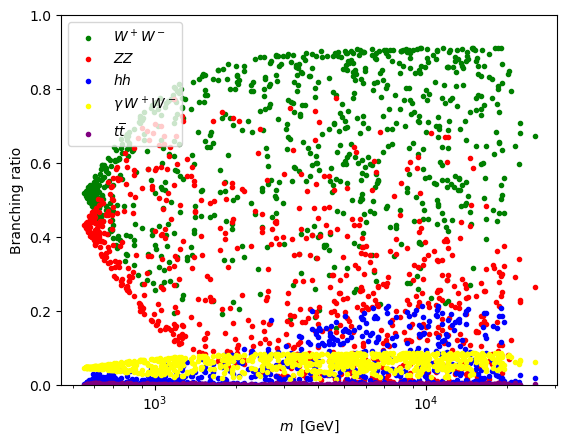

In [15]:
plt.xscale('log')
#plt.yscale('log')
plt.scatter(masses_IDM,bW,color='green',marker='.',label=r'$W^+ W^-$')
plt.scatter(masses_IDM,bZ,color='red',marker='.',label=r'$ZZ$')
plt.scatter(masses_IDM,bh,color='blue',marker='.',label=r'$hh$')
plt.scatter(masses_IDM,bA,color='yellow',marker='.',label=r'$\gamma \, W^+ W^-$')
plt.scatter(masses_IDM,bt,color='purple',marker='.',label=r'$t \overline{t}$')
plt.legend()

plt.xlabel(r'$m \,$ [GeV]')
plt.ylabel('Branching ratio')
plt.ylim(0,1)
#plt.savefig("Branching_scatter.pdf")

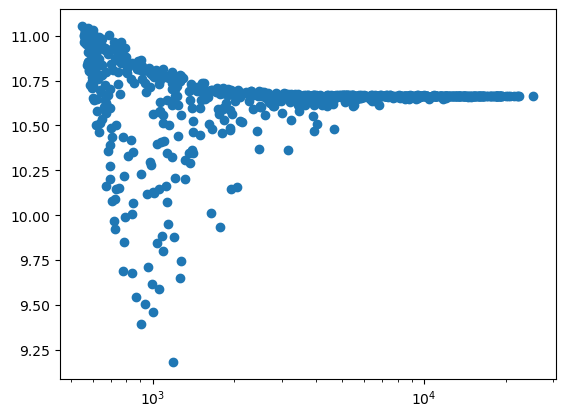

In [16]:
plt.xscale('log')

plt.scatter(masses_IDM,np.divide(bW,bA))

In [17]:
bW+bZ

array([0.926462, 0.933241, 0.942974, 0.888763, 0.941435, 0.915117,
       0.915006, 0.888909, 0.818526, 0.957167, 0.920095, 0.879559,
       0.955885, 0.943504, 0.925048, 0.929155, 0.94232 , 0.917087,
       0.826018, 0.885783, 0.881583, 0.738982, 0.761214, 0.934162,
       0.947989, 0.940756, 0.903289, 0.933809, 0.859053, 0.915645,
       0.93636 , 0.914971, 0.900672, 0.916306, 0.944228, 0.762258,
       0.942009, 0.887122, 0.935327, 0.904458, 0.797318, 0.916107,
       0.885315, 0.884562, 0.930746, 0.929292, 0.916132, 0.934422,
       0.914497, 0.841684, 0.932579, 0.944067, 0.888141, 0.917616,
       0.924228, 0.947299, 0.916698, 0.899087, 0.81835 , 0.941466,
       0.810071, 0.926904, 0.931104, 0.922211, 0.923843, 0.927494,
       0.934105, 0.935558, 0.914944, 0.931023, 0.935591, 0.914189,
       0.966464, 0.938081, 0.922902, 0.790617, 0.914872, 0.944471,
       0.923475, 0.931819, 0.915226, 0.753445, 0.915929, 0.940627,
       0.93341 , 0.94186 , 0.80222 , 0.9229  , 0.946009, 0.914

In [18]:
data1 = data[( ( data['MDM'] <= 700 ) & (data['MDM']  >= 600)  )]
data2 = data[( ( data['MDM'] <= 2000 ) & (data['MDM']  >= 1500)  )]
data3 = data[( ( data['MDM'] <= 20000 ) & (data['MDM']  >= 15000)  )]

(0.0, 1.0)

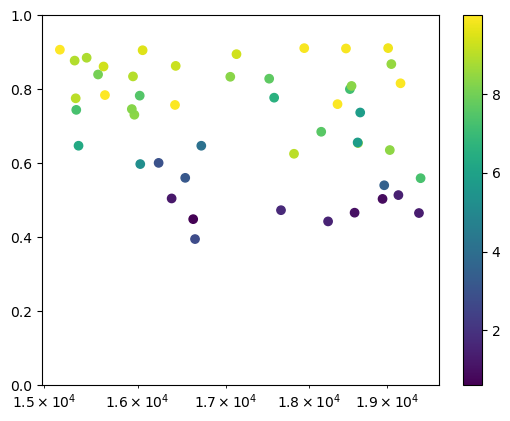

In [19]:
plt.xscale('log')
#plt.yscale('log')
plt.scatter(data3['MDM'],data3['BRWW'],c = data3['d'])
plt.colorbar()
plt.ylim(0,1)

(0.0, 1.0)

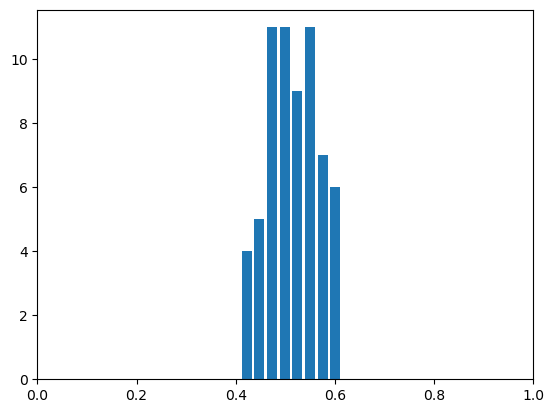

In [20]:
plt.hist(data1['BRWW'],round(150*np.std(data1['BRWW'])),rwidth=0.8)
plt.xlim(0,1)

In [21]:
round(np.std(data1['BRWW'])*100)

5

In [22]:
data1['BRAWW']

array([0.054234, 0.052855, 0.055927, 0.044837, 0.047855, 0.051271,
       0.045976, 0.045663, 0.052016, 0.051062, 0.050304, 0.05369 ,
       0.040553, 0.04501 , 0.043768, 0.043042, 0.046186, 0.045943,
       0.04889 , 0.044431, 0.054248, 0.047072, 0.043384, 0.048378,
       0.04459 , 0.04931 , 0.04611 , 0.053883, 0.04095 , 0.046449,
       0.05321 , 0.05112 , 0.048108, 0.04401 , 0.04477 , 0.044564,
       0.046296, 0.04353 , 0.048698, 0.047655, 0.046593, 0.045008,
       0.050459, 0.041951, 0.054095, 0.045177, 0.049673, 0.045189,
       0.052985, 0.04774 , 0.05053 , 0.051382, 0.047156, 0.049574,
       0.040632, 0.04542 , 0.047579, 0.051114, 0.0499  , 0.051813,
       0.050954, 0.042955, 0.040251, 0.056108])

(0.0, 1.0)

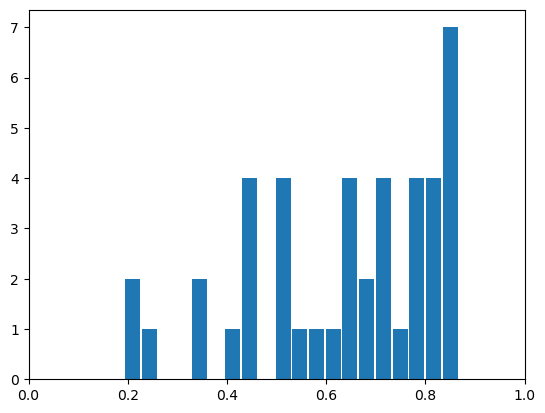

In [23]:
plt.hist(data2['BRWW'],20,rwidth=0.9)
plt.xlim(0,1)

(0.0, 1.0)

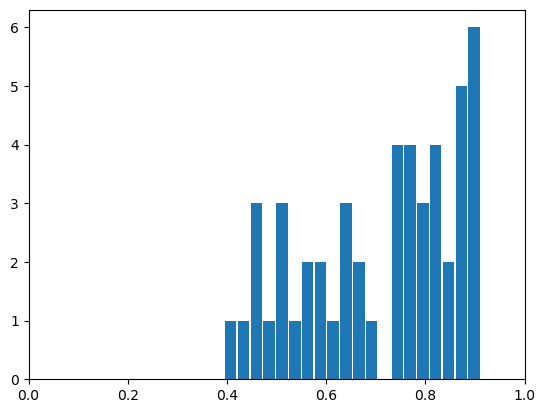

In [21]:
plt.hist(data3['BRWW'],20,rwidth=0.9)
plt.xlim(0,1)

In [117]:
np.linspace(0,1,11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [126]:
np.arange(0,1,0.02)

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98])

(0.0, 1.0)

<Figure size 640x480 with 0 Axes>

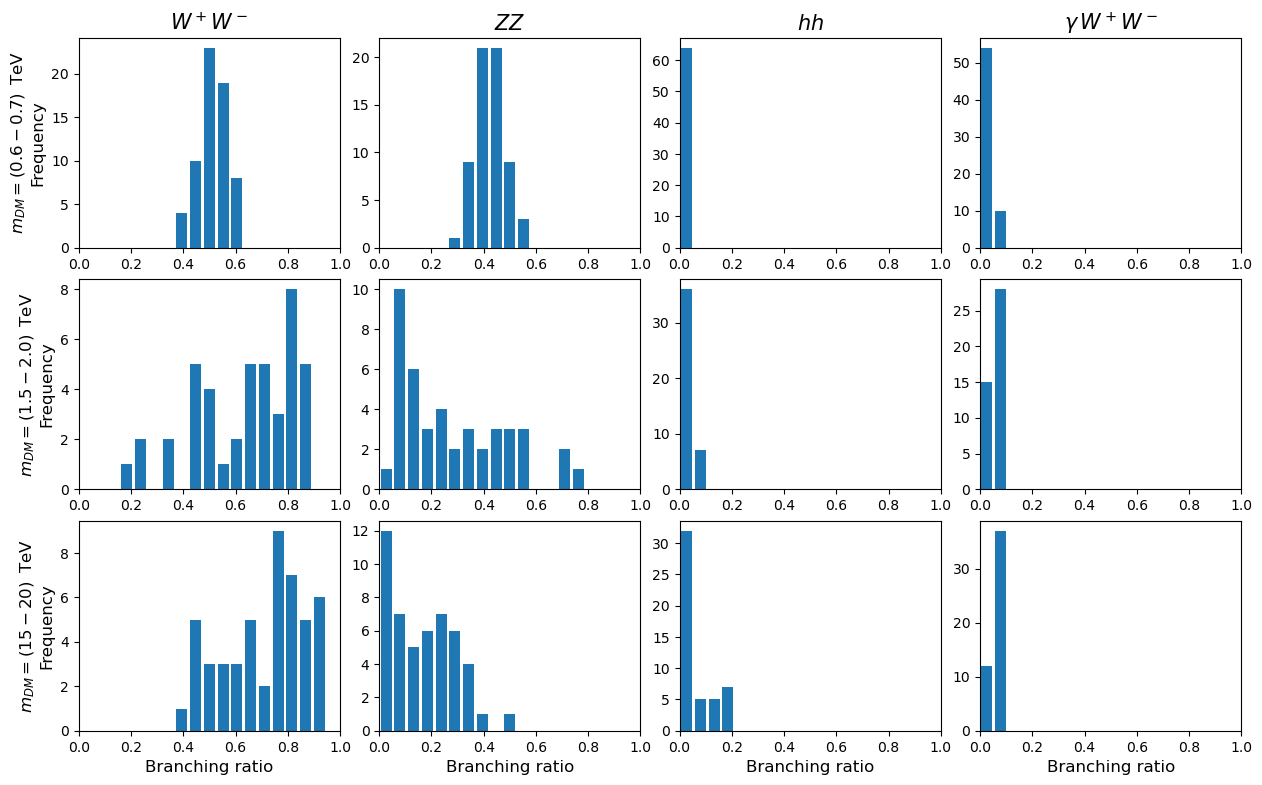

In [24]:
plt.figure(5)
fig, axs = plt.subplots(3, 4,figsize=(15,9), sharey=False)
fig.subplots_adjust(hspace=0.15,wspace=0.15)# 0.023 0.05

axs[0,0].hist(data1['BRWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[0,1].hist(data1['BRZZ'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[0,2].hist(data1['BRhh'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[0,3].hist(data1['BRAWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)

axs[1,0].hist(data2['BRWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[1,1].hist(data2['BRZZ'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[1,2].hist(data2['BRhh'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[1,3].hist(data2['BRAWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)

axs[2,0].hist(data3['BRWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[2,1].hist(data3['BRZZ'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[2,2].hist(data3['BRhh'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)
axs[2,3].hist(data3['BRAWW'],bins=np.linspace(0,1,round(1/0.05)),rwidth=0.8)

axs[0,0].set_ylabel(r"$ m_{DM} = \left( 0.6 - 0.7 \right) \, $ TeV "+"\n"+"Frequency",fontsize=12)
axs[1,0].set_ylabel(r"$ m_{DM} = \left( 1.5 - 2.0 \right) \, $ TeV "+"\n"+"Frequency",fontsize=12)
axs[2,0].set_ylabel(r"$ m_{DM} = \left( 15 - 20 \right) \, $ TeV "+"\n"+"Frequency",fontsize=12)

axs[2,0].set_xlabel('Branching ratio',fontsize=12)
axs[2,1].set_xlabel('Branching ratio',fontsize=12)
axs[2,2].set_xlabel('Branching ratio',fontsize=12)
axs[2,3].set_xlabel('Branching ratio',fontsize=12)

axs[0,0].set_title(r"$W^+ W^-$",fontsize=15)
axs[0,1].set_title(r"$Z Z$",fontsize=15)
axs[0,2].set_title(r"$h h$",fontsize=15)
axs[0,3].set_title(r"$\gamma \, W^+ W^-$",fontsize=15)

axs[0,0].set_xlim(0,1)
axs[0,1].set_xlim(0,1)
axs[0,2].set_xlim(0,1)
axs[0,3].set_xlim(0,1)

axs[1,0].set_xlim(0,1)
axs[1,1].set_xlim(0,1)
axs[1,2].set_xlim(0,1)
axs[1,3].set_xlim(0,1)

axs[2,0].set_xlim(0,1)
axs[2,1].set_xlim(0,1)
axs[2,2].set_xlim(0,1)
axs[2,3].set_xlim(0,1)

#plt.savefig('IDM_hist.pdf')


# Indirect Detection Limits

In [14]:
filenames_CA = [
    'CA_sig_11all','CA_sig_12all','CA_sig_13all','CA_sig_14all',
    'CA_sig_21all','CA_sig_22all','CA_sig_23all','CA_sig_24all',
    'CA_sig_31all','CA_sig_32all','CA_sig_33all','CA_sig_34all',
    'CA_sig_41all','CA_sig_42all','CA_sig_43all','CA_sig_44all'  
            ] # gamma spectrum filenames

benchmark = [
    '11','12','13','14',
    '21','22','23','24',
    '31','32','33','34',
    '41','42','43','44'
        ]


#table_ID = open('ID11.dat','r')
#table_ID.readline()
#table_ID.readline()
#table_ID.readline()
#Columns_ID = table_ID.readline().split()

#data_ID = np.genfromtxt('ID11.dat',dtype=float, comments='#')[1:,:]
#table_ID.close()

#values_ID = pd.DataFrame(data_ID,columns=Columns_ID)
#values_ID


#values_ID = []
sigmav_CA = []
sigmav_CTA = []
sigmav_HESS = []
sigmav_HESS546 = []
sigmav_CD = []
mass_range = []
mass_range_DD = []

for b in benchmark:
    #table_ID = open('ID'+b+'.dat','r')
    #table_ID.readline()
    #table_ID.readline()
    #table_ID.readline()
    #Columns_ID = table_ID.readline().split()

    #data_ID = np.genfromtxt('ID'+b+'.dat',dtype=float, comments='#')[1:,:]
    #table_ID.close()

    #values_ID.append(pd.DataFrame(data_ID,columns=Columns_ID)
    if ((b != '44') and (b != '14')):
        sigmav_CA.append(Sigma_CA('CA_sig_'+b+'all'))
        sigmav_CTA.append(ID_limits('ID'+b+'.dat')[1])
        sigmav_HESS.append(ID_limits('ID_HESS'+b+'.dat')[1])
        sigmav_HESS546.append(ID_limits('ID_HESS'+b+'_546h.dat')[1])
        mass_range.append(masses_list('CA_sig_'+b+'all'))
        
    else:
        sigmav_CA.append([])
        sigmav_CTA.append([])
        sigmav_HESS.append([])
        sigmav_HESS546.append([])
        mass_range.append([])

    #print(b)    
    sigmav_CD.append(Sigma_CA('CD_sig_'+b+'all_XENONnT'))
    #mass_range_DD.append(masses_list('CD_sig_'+b+'all'))
    mass_range_DD.append(masses_list('CD_sig_'+b+'all_XENONnT'))
    #values_ID
    #print(Sigma_CA('CA_sig_'+b+'all'))
mass_WW, sigmav_WW = ID_limits('HESS_WW_546h.dat')
mass_ZZ, sigmav_ZZ = ID_limits('HESS_ZZ_546h.dat')
mass_hh, sigmav_hh = ID_limits('HESS_hh_546h.dat')
    


In [26]:
sWW = interp1d(mass_WW,sigmav_WW)
sZZ = interp1d(mass_ZZ,sigmav_ZZ)
shh = interp1d(mass_hh,sigmav_hh)

In [29]:
brWW,brZZ,brhh = branching('Branching_ratios11_all.dat')
np.size(brWW)
#np.size(mass_range[0])

sigmav_mean = []

for i in range(len(mass_range[0])):
    sigmav_mean.append((brWW[i]+brZZ[i]+brhh[i])/(brWW[i]/sWW(mass_range[0][i]) + brZZ[i]/sZZ(mass_range[0][i]) + brhh[i]/shh(mass_range[0][i])))
    
sigmav_mean = np.array(sigmav_mean)    



In [30]:
i = 0
(brWW[i]+brZZ[i]+brhh[i])/(brWW[i]/sWW(mass_range[0][i]) + brZZ[i]/sZZ(mass_range[0][i]) + brhh[i]/shh(mass_range[0][i]))

5.657072903106321e-26

In [31]:
print(sigmav_mean)

[5.65707290e-26 5.54883328e-26 5.44042576e-26 5.33098830e-26
 5.22024842e-26 5.05191385e-26 4.96563071e-26 4.73483037e-26
 4.66180381e-26 4.24821381e-26 4.11572831e-26 4.07130653e-26
 3.57877977e-26 3.44285757e-26 3.36784905e-26 3.33949835e-26
 3.31960117e-26 3.44466085e-26 3.55553231e-26 3.77567761e-26
 3.84943895e-26 4.28832957e-26 4.41430782e-26 5.23951198e-26
 5.43087973e-26 6.98525445e-26 7.30018567e-26 9.78685425e-26
 1.02742866e-25]


In [32]:
mass_range[0]

array([  554.28,   565.36,   576.67,   588.2 ,   599.97,   624.21,
         636.69,   675.66,   689.17,   791.64,   840.1 ,   856.9 ,
        1176.3 ,  1351.2 ,  1491.9 ,  1614.9 ,  2048.  ,  2702.3 ,
        3104.1 ,  3783.9 ,  4015.5 ,  5194.5 ,  5512.5 ,  7567.4 ,
        8030.6 , 11699.  , 12415.  , 18087.  , 19194.  ])

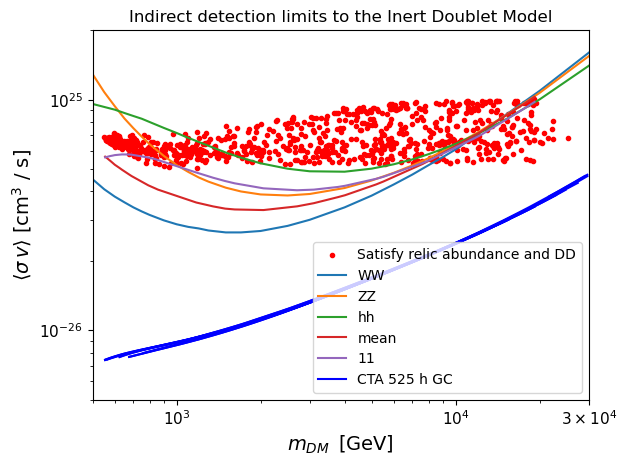

In [33]:
plt.xscale('log')
plt.yscale('log')

plt.scatter(masses_IDM,sigmav_IDM,marker='.',color='red',label=r'Satisfy relic abundance and DD')

plt.plot(mass_WW,sigmav_WW,label='WW')
plt.plot(mass_ZZ,sigmav_ZZ,label='ZZ')
plt.plot(mass_hh,sigmav_hh,label='hh')
plt.plot(mass_range[0],sigmav_mean,label='mean')

#plt.plot(mass_range[0],sigmav_HESS546[0],color='blueviolet',label='HESS 546 h GC')
#plt.plot(mass_range[1],sigmav_HESS546[1],color='blueviolet')
#plt.plot(mass_range[2],sigmav_HESS546[2],color='blueviolet')
#plt.plot(mass_range[3],sigmav_HESS546[3],color='blueviolet')
#plt.plot(mass_range[4],sigmav_HESS546[4],color='blueviolet')
#plt.plot(mass_range[5],sigmav_HESS546[5],color='blueviolet')
#plt.plot(mass_range[6],sigmav_HESS546[6],color='blueviolet')
#plt.plot(mass_range[7],sigmav_HESS546[7],color='blueviolet')
#plt.plot(mass_range[8],sigmav_HESS546[8],color='blueviolet')
#plt.plot(mass_range[9],sigmav_HESS546[9],color='blueviolet')
#plt.plot(mass_range[10],sigmav_HESS546[10],color='blueviolet')
#plt.plot(mass_range[11],sigmav_HESS546[11],color='blueviolet')
#plt.plot(mass_range[12],sigmav_HESS546[12],color='blueviolet')
#plt.plot(mass_range[13],sigmav_HESS546[13],color='blueviolet')

plt.plot(mass_range[0],sigmav_HESS546[0],label='11')
#plt.plot(mass_range[1],sigmav_HESS546[1])
#plt.plot(mass_range[2],sigmav_HESS546[2],label='13')
#plt.plot(mass_range[3],sigmav_HESS546[3])
#plt.plot(mass_range[4],sigmav_HESS546[4])
#plt.plot(mass_range[5],sigmav_HESS546[5])
#plt.plot(mass_range[6],sigmav_HESS546[6])
#plt.plot(mass_range[7],sigmav_HESS546[7],label='11')
#plt.plot(mass_range[8],sigmav_HESS546[8])
#plt.plot(mass_range[9],sigmav_HESS546[9])
#plt.plot(mass_range[10],sigmav_HESS546[10])
#plt.plot(mass_range[11],sigmav_HESS546[11],label='34')
#plt.plot(mass_range[12],sigmav_HESS546[12],label='41')
#plt.plot(mass_range[13],sigmav_HESS546[13],label='11')
#plt.plot(mass_range[14],sigmav_HESS546[14],label='43')
#plt.plot(mass_range[14],sigmav_HESS546[14])

plt.plot(mass_range[0],sigmav_CTA[0],color='blue',label='CTA 525 h GC')
plt.plot(mass_range[1],sigmav_CTA[1],color='blue')
plt.plot(mass_range[2],sigmav_CTA[2],color='blue')
plt.plot(mass_range[3],sigmav_CTA[3],color='blue')
plt.plot(mass_range[4],sigmav_CTA[4],color='blue')
plt.plot(mass_range[5],sigmav_CTA[5],color='blue')
plt.plot(mass_range[6],sigmav_CTA[6],color='blue')
plt.plot(mass_range[7],sigmav_CTA[7],color='blue')
plt.plot(mass_range[8],sigmav_CTA[8],color='blue')
plt.plot(mass_range[9],sigmav_CTA[9],color='blue')
plt.plot(mass_range[10],sigmav_CTA[10],color='blue')
plt.plot(mass_range[11],sigmav_CTA[11],color='blue')
plt.plot(mass_range[12],sigmav_CTA[12],color='blue')
plt.plot(mass_range[13],sigmav_CTA[13],color='blue')


plt.xlabel(r'$m_{DM} \,$ [GeV]',fontsize=14)
plt.ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$ / s]',fontsize=14)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 10^3$',r'$10^4$',r'$3 \times 10^4$']

s_list = [1e-27,1e-26,1e-25,1e-24]
s_label = [r'$ 10^{-27}$',r'$10^{-26}$',r'$ 10^{25}$',r'$ 10^{24}$']


plt.xticks(mass_list,mass_label,fontsize=11)
plt.yticks(s_list,s_label,fontsize=11)

plt.title('Indirect detection limits to the Inert Doublet Model')

plt.xlim(5e2,3e4)
plt.ylim(5e-27,2e-25)

plt.legend()
#plt.savefig('IDM_continuous_limits2.pdf')

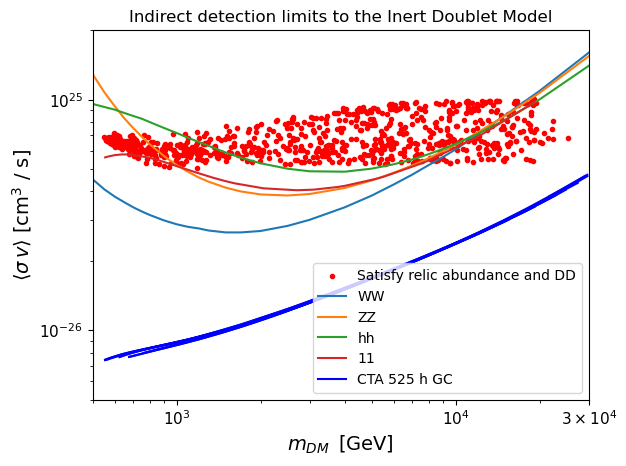

In [24]:
plt.xscale('log')
plt.yscale('log')

plt.scatter(masses_IDM,sigmav_IDM,marker='.',color='red',label=r'Satisfy relic abundance and DD')

plt.plot(mass_WW,sigmav_WW,label='WW')
plt.plot(mass_ZZ,sigmav_ZZ,label='ZZ')
plt.plot(mass_hh,sigmav_hh,label='hh')

#plt.plot(mass_range[0],sigmav_HESS546[0],color='blueviolet',label='HESS 546 h GC')
#plt.plot(mass_range[1],sigmav_HESS546[1],color='blueviolet')
#plt.plot(mass_range[2],sigmav_HESS546[2],color='blueviolet')
#plt.plot(mass_range[3],sigmav_HESS546[3],color='blueviolet')
#plt.plot(mass_range[4],sigmav_HESS546[4],color='blueviolet')
#plt.plot(mass_range[5],sigmav_HESS546[5],color='blueviolet')
#plt.plot(mass_range[6],sigmav_HESS546[6],color='blueviolet')
#plt.plot(mass_range[7],sigmav_HESS546[7],color='blueviolet')
#plt.plot(mass_range[8],sigmav_HESS546[8],color='blueviolet')
#plt.plot(mass_range[9],sigmav_HESS546[9],color='blueviolet')
#plt.plot(mass_range[10],sigmav_HESS546[10],color='blueviolet')
#plt.plot(mass_range[11],sigmav_HESS546[11],color='blueviolet')
#plt.plot(mass_range[12],sigmav_HESS546[12],color='blueviolet')
#plt.plot(mass_range[13],sigmav_HESS546[13],color='blueviolet')

plt.plot(mass_range[0],sigmav_HESS546[0],label='11')
#plt.plot(mass_range[1],sigmav_HESS546[1])
#plt.plot(mass_range[2],sigmav_HESS546[2],label='13')
#plt.plot(mass_range[3],sigmav_HESS546[3])
#plt.plot(mass_range[4],sigmav_HESS546[4])
#plt.plot(mass_range[5],sigmav_HESS546[5])
#plt.plot(mass_range[6],sigmav_HESS546[6])
#plt.plot(mass_range[7],sigmav_HESS546[7],label='11')
#plt.plot(mass_range[8],sigmav_HESS546[8])
#plt.plot(mass_range[9],sigmav_HESS546[9])
#plt.plot(mass_range[10],sigmav_HESS546[10])
#plt.plot(mass_range[11],sigmav_HESS546[11],label='34')
#plt.plot(mass_range[12],sigmav_HESS546[12],label='41')
#plt.plot(mass_range[13],sigmav_HESS546[13],label='11')
#plt.plot(mass_range[14],sigmav_HESS546[14],label='43')
#plt.plot(mass_range[14],sigmav_HESS546[14])

plt.plot(mass_range[0],sigmav_CTA[0],color='blue',label='CTA 525 h GC')
plt.plot(mass_range[1],sigmav_CTA[1],color='blue')
plt.plot(mass_range[2],sigmav_CTA[2],color='blue')
plt.plot(mass_range[3],sigmav_CTA[3],color='blue')
plt.plot(mass_range[4],sigmav_CTA[4],color='blue')
plt.plot(mass_range[5],sigmav_CTA[5],color='blue')
plt.plot(mass_range[6],sigmav_CTA[6],color='blue')
plt.plot(mass_range[7],sigmav_CTA[7],color='blue')
plt.plot(mass_range[8],sigmav_CTA[8],color='blue')
plt.plot(mass_range[9],sigmav_CTA[9],color='blue')
plt.plot(mass_range[10],sigmav_CTA[10],color='blue')
plt.plot(mass_range[11],sigmav_CTA[11],color='blue')
plt.plot(mass_range[12],sigmav_CTA[12],color='blue')
plt.plot(mass_range[13],sigmav_CTA[13],color='blue')


plt.xlabel(r'$m_{DM} \,$ [GeV]',fontsize=14)
plt.ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$ / s]',fontsize=14)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 10^3$',r'$10^4$',r'$3 \times 10^4$']

s_list = [1e-27,1e-26,1e-25,1e-24]
s_label = [r'$ 10^{-27}$',r'$10^{-26}$',r'$ 10^{25}$',r'$ 10^{24}$']


plt.xticks(mass_list,mass_label,fontsize=11)
plt.yticks(s_list,s_label,fontsize=11)

plt.title('Indirect detection limits to the Inert Doublet Model')

plt.xlim(5e2,3e4)
plt.ylim(5e-27,2e-25)

plt.legend()
#plt.savefig('IDM_continuous_limits2.pdf')

## Bands of indirect detection exclusion

In [15]:
filenames_CA = [
    'CA_sig_11all','CA_sig_12all','CA_sig_13all','CA_sig_14all',
    'CA_sig_21all','CA_sig_22all','CA_sig_23all','CA_sig_24all',
    'CA_sig_31all','CA_sig_32all','CA_sig_33all','CA_sig_34all',
    'CA_sig_41all','CA_sig_42all','CA_sig_43all','CA_sig_44all'  
            ] # gamma spectrum filenames

benchmark = [
    '11','12','13','14',
    '21','22','23','24',
    '31','32','33','34',
    '41','42','43','44'
        ]


#table_ID = open('ID11.dat','r')
#table_ID.readline()
#table_ID.readline()
#table_ID.readline()
#Columns_ID = table_ID.readline().split()

#data_ID = np.genfromtxt('ID11.dat',dtype=float, comments='#')[1:,:]
#table_ID.close()

#values_ID = pd.DataFrame(data_ID,columns=Columns_ID)
#values_ID


#values_ID = []


mi = []
mf = []
interlimitsHESS = []
interlimitsCTA = []

for i in range(16):
    if ((i != 3) and (i != 15)):
            mi.append(np.min(mass_range[i]))
            mf.append(np.max(mass_range[i]))
            interlimitsHESS.append(interp1d(mass_range[i],sigmav_HESS546[i]))
            interlimitsCTA.append(interp1d(mass_range[i],sigmav_CTA[i]))
            #interlimitsHESS.append(interp1d(mass_range[i],sigmav_CTA))
    else:
            interlimitsHESS.append([])
            interlimitsCTA.append([])
            
masses_total = np.geomspace(np.min(mi),np.max(mf),200)
sigmavmaxHESS = []
sigmavminHESS = []
sigmavmaxCTA = []
sigmavminCTA = []

for mass in masses_total:
    sigsampleHESS = []
    sigsampleCTA = []
    for i in range(16):
        if ((i != 3) and (i != 15)):
            if ( (mass >= mass_range[i][0]) & (mass <= mass_range[i][-1])):
                sigsampleHESS.append(interlimitsHESS[i](mass))
                sigsampleCTA.append(interlimitsCTA[i](mass))
    sigmavminHESS.append(np.min(sigsampleHESS))
    sigmavmaxHESS.append(np.max(sigsampleHESS))                
    sigmavminCTA.append(np.min(sigsampleCTA))
    sigmavmaxCTA.append(np.max(sigsampleCTA))

#HESSmax = interp1d(masses_total,sigmavmax) 

sigmavmaxHESS = np.array(sigmavmaxHESS)
sigmavminHESS = np.array(sigmavminHESS)
sigmavmaxCTA = np.array(sigmavmaxCTA)
sigmavminCTA = np.array(sigmavminCTA )


smaxhess = interp1d(masses_total,sigmavmaxHESS)
sminhess = interp1d(masses_total,sigmavminHESS)
smaxcta = interp1d(masses_total,sigmavmaxCTA)
smincta = interp1d(masses_total,sigmavminCTA)


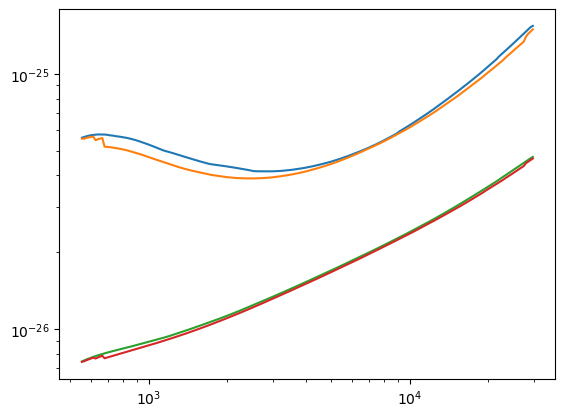

In [16]:
plt.xscale('log')
plt.yscale('log')
plt.plot(masses_total,sigmavmaxHESS)
plt.plot(masses_total,sigmavminHESS)
plt.plot(masses_total,sigmavmaxCTA)
plt.plot(masses_total,sigmavminCTA)


In [23]:
LZ = read_data('CDD_all_LZ')

In [58]:
type(LZ['Lambda345'][0])

numpy.float64

In [64]:
LZ['Lambda345'][:-28]

array([0.015126  , 0.0151325 , 0.0155865 , 0.016054  , 0.0165355 ,
       0.0170315 , 0.0175425 , 0.018069  , 0.018611  , 0.0191695 ,
       0.0197445 , 0.020337  , 0.020947  , 0.0215755 , 0.0222225 ,
       0.0228895 , 0.023576  , 0.0242835 , 0.025012  , 0.025762  ,
       0.026535  , 0.027331  , 0.028151  , 0.0289955 , 0.0298655 ,
       0.030761  , 0.031684  , 0.0326345 , 0.0336135 , 0.034622  ,
       0.035661  , 0.0367305 , 0.0378325 , 0.0389675 , 0.0401365 ,
       0.0413405 , 0.042581  , 0.043858  , 0.045174  , 0.046529  ,
       0.047925  , 0.0493625 , 0.0508435 , 0.052369  , 0.05394   ,
       0.0555585 , 0.057225  , 0.058942  , 0.06071   , 0.0625315 ,
       0.0644075 , 0.0663395 , 0.06833   , 0.0703795 , 0.071404  ,
       0.073546  , 0.076872  , 0.079178  , 0.081554  , 0.084     ,
       0.08652   , 0.089116  , 0.091789  , 0.094543  , 0.097379  ,
       0.1003    , 0.10331   , 0.10641   , 0.1096    , 0.11289   ,
       0.11628   , 0.11976   , 0.12336   , 0.12706   , 0.13087

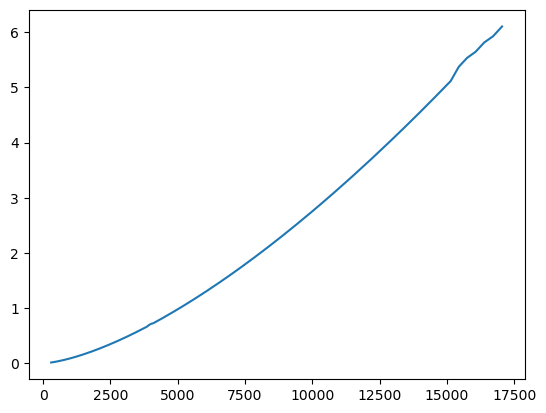

In [45]:
LZ_limit(18000)

array(nan)

In [67]:
CA = read_data(filename_CA)
max(CA['Lambda345'])

5.7189

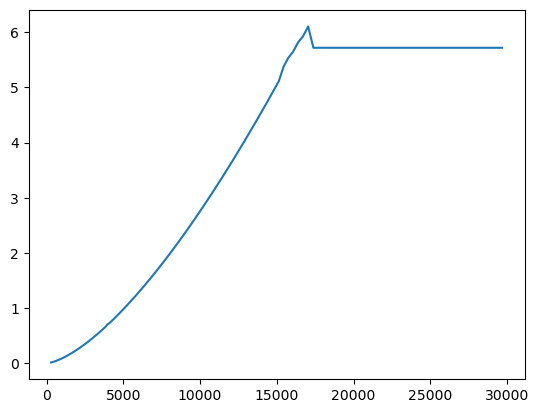

In [68]:
LZ_limit = interp1d(LZ['MDM'][:-28],LZ['Lambda345'][:-28],bounds_error=False, fill_value=max(CA['Lambda345']))
plt.plot(LZ['MDM'],LZ_limit(LZ['MDM']))

In [69]:
LZ_limit(2e4)

array(5.7189)

In [70]:
CA = CA[(CA['Lambda345'] <= LZ_limit(CA['MDM']))]

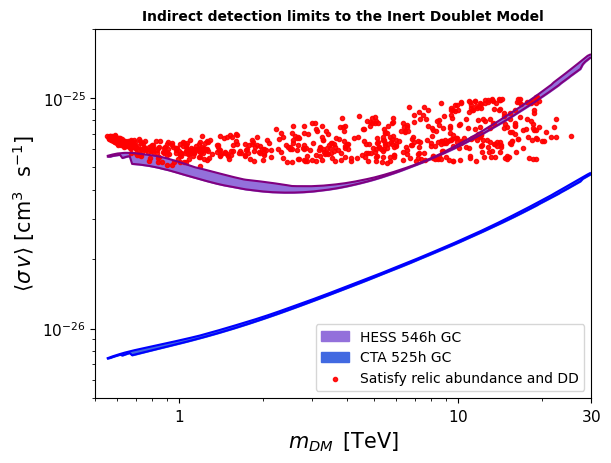

In [73]:
plt.xscale('log')
plt.yscale('log')



plt.plot(masses_total,sigmavmaxHESS,color='purple')
plt.plot(masses_total,sigmavminHESS,color='purple')
plt.plot(masses_total,sigmavmaxCTA,color='blue')
plt.plot(masses_total,sigmavminCTA,color='blue')

plt.fill_between(masses_total,sigmavminHESS,sigmavmaxHESS,color='mediumpurple',label='HESS 546h GC')
plt.fill_between(masses_total,sigmavminCTA,sigmavmaxCTA,color='royalblue',label='CTA 525h GC')

#plt.scatter(masses_IDM,sigmav_IDM,marker='.',color='red',label=r'Satisfy relic abundance and DD',alpha=0.9)
plt.scatter(CA['MDM'],CA['SigmaV'],marker='.',color='red',label=r'Satisfy relic abundance and DD',alpha=0.9)
#plt.plot(mass_WW,sigmav_WW,label='WW')
#plt.plot(mass_ZZ,sigmav_ZZ,label='ZZ')
#plt.plot(mass_hh,sigmav_hh,label='hh')

#plt.plot(mass_range[0],sigmav_HESS546[0],color='blueviolet',label='HESS 546 h GC')
#plt.plot(mass_range[1],sigmav_HESS546[1],color='blueviolet')
#plt.plot(mass_range[2],sigmav_HESS546[2],color='blueviolet')
#plt.plot(mass_range[3],sigmav_HESS546[3],color='blueviolet')
#plt.plot(mass_range[4],sigmav_HESS546[4],color='blueviolet')
#plt.plot(mass_range[5],sigmav_HESS546[5],color='blueviolet')
#plt.plot(mass_range[6],sigmav_HESS546[6],color='blueviolet')
#plt.plot(mass_range[7],sigmav_HESS546[7],color='blueviolet')
#plt.plot(mass_range[8],sigmav_HESS546[8],color='blueviolet')
#plt.plot(mass_range[9],sigmav_HESS546[9],color='blueviolet')
#plt.plot(mass_range[10],sigmav_HESS546[10],color='blueviolet')
#plt.plot(mass_range[11],sigmav_HESS546[11],color='blueviolet')
#plt.plot(mass_range[12],sigmav_HESS546[12],color='blueviolet')
#plt.plot(mass_range[13],sigmav_HESS546[13],color='blueviolet')

#plt.plot(mass_range[0],sigmav_HESS546[0],label='11')
#plt.plot(mass_range[1],sigmav_HESS546[1])
#plt.plot(mass_range[2],sigmav_HESS546[2],label='13')
#plt.plot(mass_range[3],sigmav_HESS546[3])
#plt.plot(mass_range[4],sigmav_HESS546[4])
#plt.plot(mass_range[5],sigmav_HESS546[5])
#plt.plot(mass_range[6],sigmav_HESS546[6])
#plt.plot(mass_range[7],sigmav_HESS546[7],label='11')
#plt.plot(mass_range[8],sigmav_HESS546[8])
#plt.plot(mass_range[9],sigmav_HESS546[9])
#plt.plot(mass_range[10],sigmav_HESS546[10])
#plt.plot(mass_range[11],sigmav_HESS546[11],label='34')
#plt.plot(mass_range[12],sigmav_HESS546[12],label='41')
#plt.plot(mass_range[13],sigmav_HESS546[13],label='11')
#plt.plot(mass_range[14],sigmav_HESS546[14],label='43')
#plt.plot(mass_range[14],sigmav_HESS546[14])

#plt.plot(mass_range[0],sigmav_CTA[0],color='blue',label='CTA 525 h GC')
#plt.plot(mass_range[1],sigmav_CTA[1],color='blue')
#plt.plot(mass_range[2],sigmav_CTA[2],color='blue')
#plt.plot(mass_range[3],sigmav_CTA[3],color='blue')
#plt.plot(mass_range[4],sigmav_CTA[4],color='blue')
#plt.plot(mass_range[5],sigmav_CTA[5],color='blue')
#plt.plot(mass_range[6],sigmav_CTA[6],color='blue')
#plt.plot(mass_range[7],sigmav_CTA[7],color='blue')
#plt.plot(mass_range[8],sigmav_CTA[8],color='blue')
#plt.plot(mass_range[9],sigmav_CTA[9],color='blue')
#plt.plot(mass_range[10],sigmav_CTA[10],color='blue')
#plt.plot(mass_range[11],sigmav_CTA[11],color='blue')
#plt.plot(mass_range[12],sigmav_CTA[12],color='blue')
#plt.plot(mass_range[13],sigmav_CTA[13],color='blue')


plt.xlabel(r'$m_{DM} \,$ [TeV]',fontsize=15)
plt.ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$  s$^{-1}$]',fontsize=15)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 1$',r'$10$',r'$30$']

#s_list = [1e-27,1e-26,1e-25,1e-24]
#s_label = [r'$ 10^{-27}$',r'$10^{-26}$',r'$ 10^{-25}$',r'$ 10^{-24}$']
s_list = [1e-26,1e-25]
s_label = [r'$10^{-26}$',r'$ 10^{-25}$']

plt.xticks(mass_list,mass_label,fontsize=11)
plt.yticks(s_list,s_label,fontsize=11)

plt.title(r'Indirect detection limits to the Inert Doublet Model',weight='bold',fontsize=10)

plt.xlim(5e2,3e4)
plt.ylim(5e-27,2e-25)

plt.legend(loc='lower right')
plt.savefig('IDM_continuous_limits_final_LZ.pdf',bbox_inches='tight')

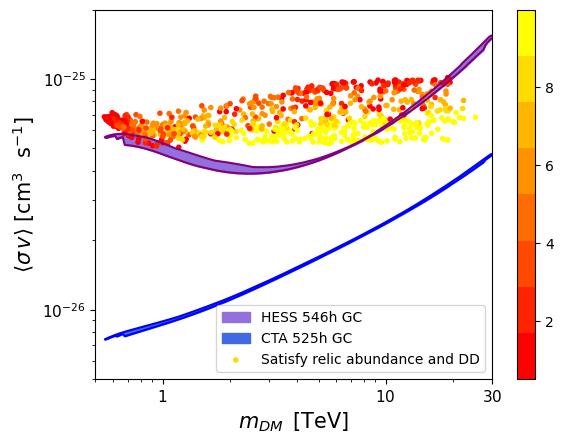

In [65]:
plt.xscale('log')
plt.yscale('log')

cmap = plt.cm.autumn  # define the colormap
#cmap = plt.cm.inferno
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N/30)


plt.plot(masses_total,sigmavmaxHESS,color='purple')
plt.plot(masses_total,sigmavminHESS,color='purple')
plt.plot(masses_total,sigmavmaxCTA,color='blue')
plt.plot(masses_total,sigmavminCTA,color='blue')

plt.fill_between(masses_total,sigmavminHESS,sigmavmaxHESS,color='mediumpurple',label='HESS 546h GC')
plt.fill_between(masses_total,sigmavminCTA,sigmavmaxCTA,color='royalblue',label='CTA 525h GC')

plt.scatter(masses_IDM,sigmav_IDM,marker='.',label=r'Satisfy relic abundance and DD',c=data['d'],cmap=cmap)

plt.xlabel(r'$m_{DM} \,$ [TeV]',fontsize=15)
plt.ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$  s$^{-1}$]',fontsize=15)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 1$',r'$10$',r'$30$']

#s_list = [1e-27,1e-26,1e-25,1e-24]
#s_label = [r'$ 10^{-27}$',r'$10^{-26}$',r'$ 10^{-25}$',r'$ 10^{-24}$']
s_list = [1e-26,1e-25]
s_label = [r'$10^{-26}$',r'$ 10^{-25}$']

plt.xticks(mass_list,mass_label,fontsize=11)
plt.yticks(s_list,s_label,fontsize=11)

#plt.title(r'Indirect detection limits to the Inert Doublet Model',weight='bold',fontsize=10)

plt.xlim(5e2,3e4)
plt.ylim(5e-27,2e-25)
plt.colorbar()

plt.legend(loc='lower right')
#plt.savefig('IDM_continuous_limits_final.pdf',bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

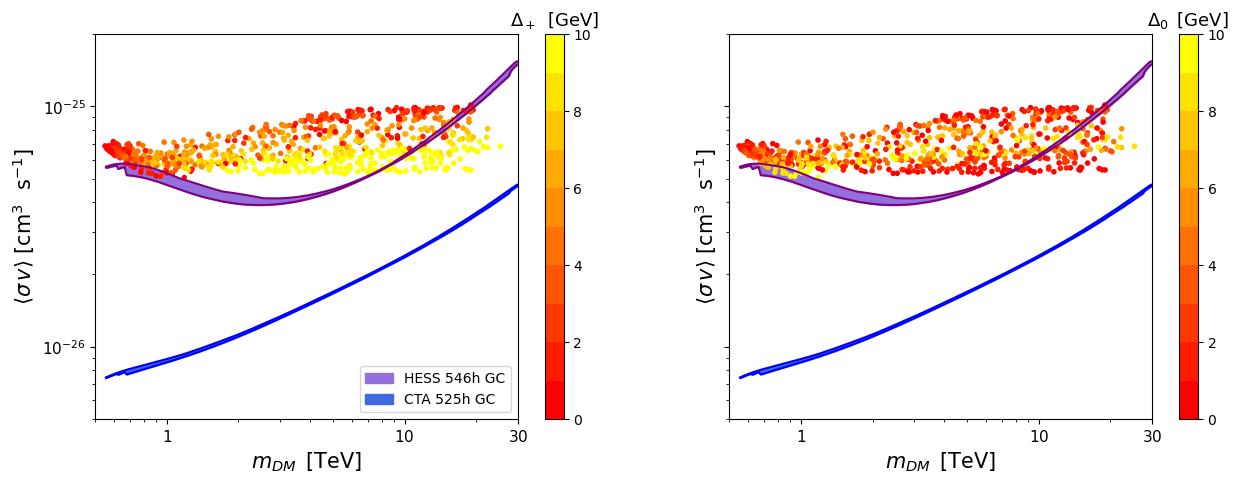

In [157]:
plt.figure(11)
fig, axs = plt.subplots(1, 2,figsize=(15,5), sharey=True)
fig.subplots_adjust(hspace=0.25,wspace=0.2)

cmap = plt.cm.autumn  # define the colormap
#cmap = plt.cm.inferno
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, 10)#cmap.N/2

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].plot(masses_total,sigmavmaxHESS,color='purple')
axs[0].plot(masses_total,sigmavminHESS,color='purple')
axs[0].plot(masses_total,sigmavmaxCTA,color='blue')
axs[0].plot(masses_total,sigmavminCTA,color='blue')

axs[0].fill_between(masses_total,sigmavminHESS,sigmavmaxHESS,color='mediumpurple',label='HESS 546h GC')
axs[0].fill_between(masses_total,sigmavminCTA,sigmavmaxCTA,color='royalblue',label='CTA 525h GC')

im1 = axs[0].scatter(masses_IDM,sigmav_IDM,marker='.',c=data['d'],cmap=cmap,vmin=0.0,vmax=10)

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].plot(masses_total,sigmavmaxHESS,color='purple')
axs[1].plot(masses_total,sigmavminHESS,color='purple')
axs[1].plot(masses_total,sigmavmaxCTA,color='blue')
axs[1].plot(masses_total,sigmavminCTA,color='blue')

axs[1].fill_between(masses_total,sigmavminHESS,sigmavmaxHESS,color='mediumpurple',label='HESS 546h GC')
axs[1].fill_between(masses_total,sigmavminCTA,sigmavmaxCTA,color='royalblue',label='CTA 525h GC')

im2 = axs[1].scatter(masses_IDM,sigmav_IDM,marker='.',c=data['d0'],cmap=cmap,vmin=0.0,vmax=10)


cbar1 = fig.colorbar(im1,ax = axs[0])
#fig.colorbar(im2,ax = axs[0])

cbar1.ax.tick_params(labelsize=10)
cbar1.ax.set_title(r'$ \Delta_+ \,$ [GeV]',fontsize=13)

cbar2 = fig.colorbar(im2,ax = axs[1])
#fig.colorbar(im2,ax = axs[1])

cbar2.ax.tick_params(labelsize=10)
cbar2.ax.set_title(r'$ \Delta_0 \,$ [GeV]',fontsize=13)

axs[0].set_xlabel(r'$m_{DM} \,$ [TeV]',fontsize=15)
axs[0].set_ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$  s$^{-1}$]',fontsize=15)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 1$',r'$10$',r'$30$']
s_list = [1e-26,1e-25]
s_label = [r'$10^{-26}$',r'$ 10^{-25}$']
axs[0].set_xticks(mass_list,mass_label,fontsize=11)
axs[0].set_yticks(s_list,s_label,fontsize=11)

axs[0].set_xlim(5e2,3e4)
axs[0].set_ylim(5e-27,2e-25)

axs[1].set_xlabel(r'$m_{DM} \,$ [TeV]',fontsize=15)
axs[1].set_ylabel(r'$\left< \sigma \, v \right>$ [cm$^3$  s$^{-1}$]',fontsize=15)

mass_list = [1e3,1e4,3e4]
mass_label = [r'$ 1$',r'$10$',r'$30$']
s_list = [1e-26,1e-25]
s_label = [r'$10^{-26}$',r'$ 10^{-25}$']
axs[1].set_xticks(mass_list,mass_label,fontsize=11)
axs[1].set_yticks(s_list,s_label,fontsize=11)

axs[1].set_xlim(5e2,3e4)
axs[1].set_ylim(5e-27,2e-25)

axs[0].legend(loc='lower right')

plt.savefig('IDM_continuous_limits_delta.pdf',bbox_inches='tight')

In [101]:
masses_total

array([  554.28      ,   565.47811615,   576.90246778,   588.55762554,
         600.44825239,   612.57910552,   624.95503821,   637.58100181,
         650.4620477 ,   663.60332929,   677.01010413,   690.68773597,
         704.64169695,   718.87756973,   733.40104978,   748.21794763,
         763.33419119,   778.75582815,   794.48902836,   810.54008635,
         826.91542378,   843.62159207,   860.66527499,   878.05329137,
         895.79259775,   913.89029125,   932.35361237,   951.18994787,
         970.40683377,   990.01195832,  1010.01316511,  1030.41845618,
        1051.23599524,  1072.47411095,  1094.14130021,  1116.24623158,
        1138.79774878,  1161.80487417,  1185.2768124 ,  1209.22295408,
        1233.65287955,  1258.57636269,  1284.00337483,  1309.94408878,
        1336.40888284,  1363.40834501,  1390.95327719,  1419.05469949,
        1447.7238547 ,  1476.9722127 ,  1506.81147514,  1537.25358006,
        1568.31070667,  1599.99528026,  1632.31997714,  1665.29772971,
      

In [54]:
masses_total = np.geomspace(np.min(mi),np.max(mf),100)
masses_total

array([  554.28      ,   577.01903497,   600.69092645,   625.33394438,
         650.9879287 ,   677.69435374,   705.49639532,   734.4390005 ,
         764.56896029,   795.93498526,   828.58778432,   862.58014666,
         897.96702714,   934.80563512,   973.15552691,  1013.07870212,
        1054.63970383,  1097.90572299,  1142.94670701,  1189.83547286,
        1238.64782478,  1289.46267683,  1342.3621805 ,  1397.43185749,
        1454.76073796,  1514.44150452,  1576.570642  ,  1641.24859349,
        1708.5799227 ,  1778.673483  ,  1851.64259342,  1927.60522183,
        2006.68417567,  2089.00730051,  2174.70768668,  2263.9238845 ,
        2356.80012822,  2453.48656923,  2554.13951879,  2658.92170077,
        2768.00251466,  2881.5583095 ,  2999.77266894,  3122.83670807,
        3250.94938234,  3384.31780927,  3523.15760323,  3667.69322408,
        3818.15834003,  3974.79620536,  4137.86005376,  4307.61350769,
        4484.33100457,  4668.29824045,  4859.81263195,  5059.183797  ,
      

Text(0.5, 0.98, 'Limits to IDM')

<Figure size 640x480 with 0 Axes>

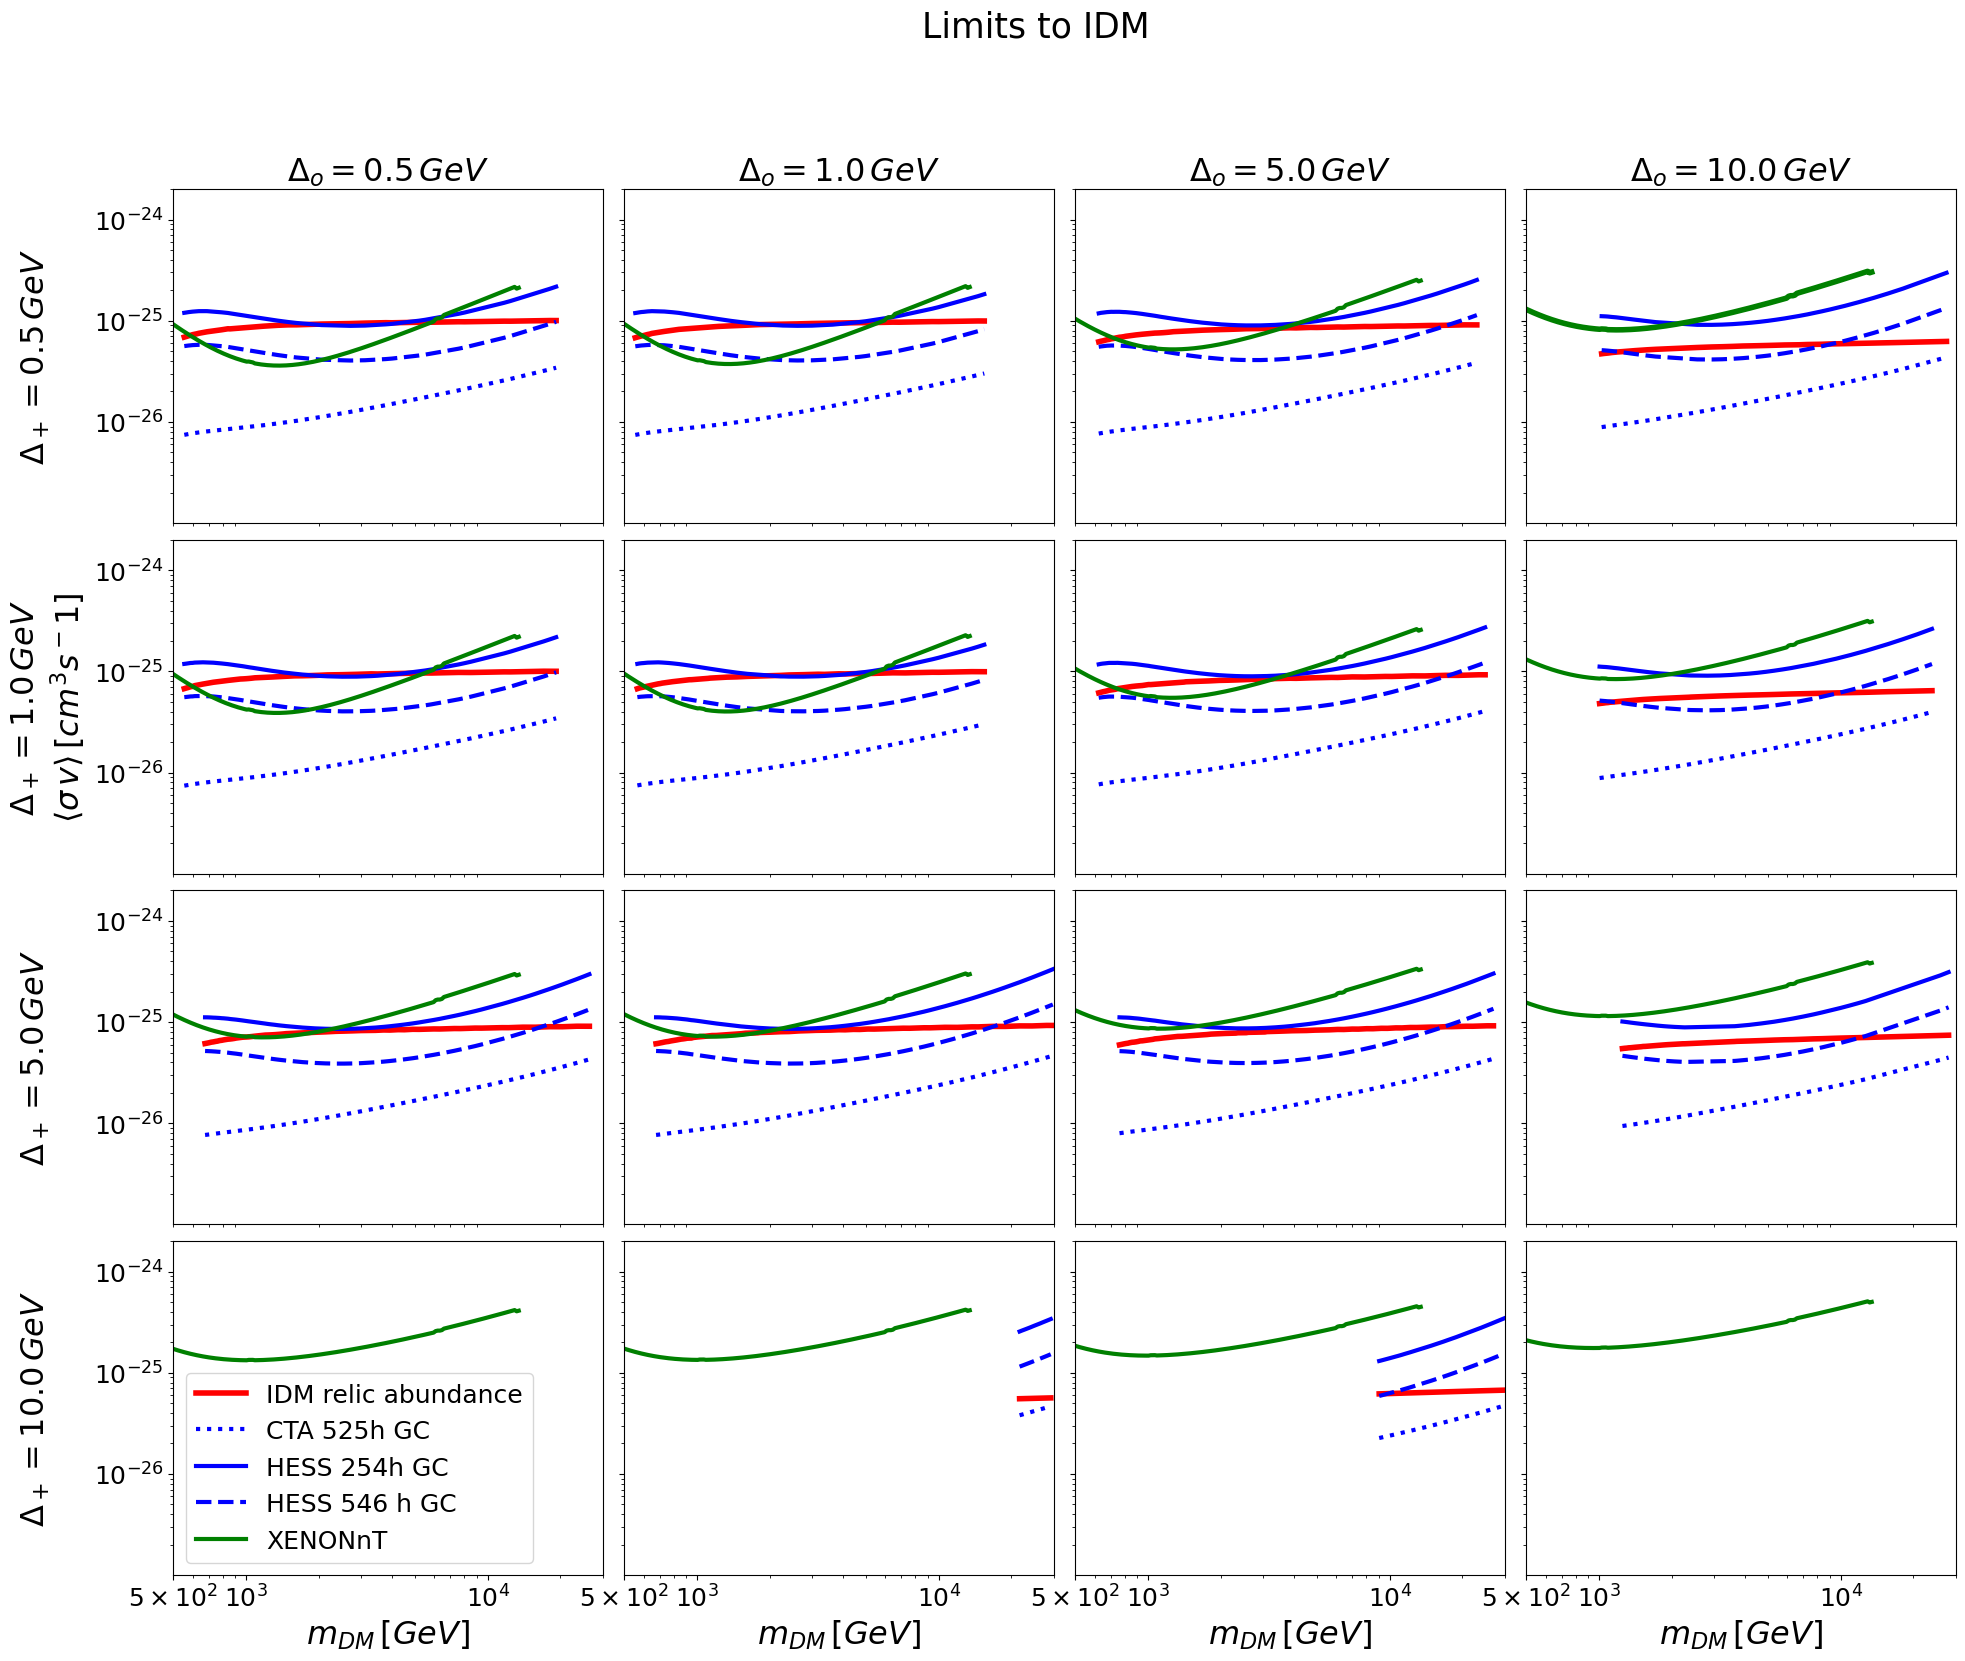

In [13]:
plt.figure(5)
fig, axs = plt.subplots(4, 4,figsize=(23,18), sharey=True)
fig.subplots_adjust(hspace=0.05,wspace=0.05)# 0.023 0.05


axs[0,0].plot(mass_range[0],sigmav_CA[0],label='Relic abundance for IDM',color='red',linewidth=4)
axs[0,0].plot(mass_range[0],sigmav_ID[0],label='CTA 500 h GC',color='blue',linestyle='dotted',linewidth=3)
axs[0,0].plot(mass_range[0],sigmav_HESS[0],label='HESS 254 h GC',color='blue',linestyle='solid',linewidth=3)
axs[0,0].plot(mass_range[0],sigmav_HESS546[0],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[0,0].plot(mass_range_DD[0],sigmav_CD[0],label='XENONnT',color='green',linewidth=3)
#axs[0,0].plot(mass_range[0],values_ID[0]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,0].axhline(y=3e-26,color='red')
#axs[0,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,1].plot(mass_range[4],sigmav_CA[4],label='Relic abundance for IDM',color='red',linewidth=4)
axs[0,1].plot(mass_range[4],sigmav_ID[4],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[0,1].plot(mass_range[4],sigmav_HESS[4],label='HESS',color='blue',linestyle='solid',linewidth=3)
axs[0,1].plot(mass_range[4],sigmav_HESS546[4],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[0,1].plot(mass_range_DD[4],sigmav_CD[4],label='DD exclusion',color='green',linewidth=3)
#axs[0,1].plot(mass_range[3],values_ID[3]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,1].axhline(y=3e-26,color='red')
#axs[0,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,2].plot(mass_range[8],sigmav_CA[8],label='Relic abundance for IDM',color='red',linewidth=4)
axs[0,2].plot(mass_range[8],sigmav_ID[8],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[0,2].plot(mass_range[8],sigmav_HESS[8],label='HESS',color='blue',linestyle='solid',linewidth=3)
axs[0,2].plot(mass_range[8],sigmav_HESS546[8],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[0,2].plot(mass_range_DD[8],sigmav_CD[8],label='DD exclusion',color='green',linewidth=3)
#axs[0,2].plot(mass_range[6],values_ID[6]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,2].axhline(y=3e-26,color='red')
#axs[0,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,3].plot(mass_range[12],sigmav_CA[12],label='Relic abundance for IDM',color='red',linewidth=4)
axs[0,3].plot(mass_range[12],sigmav_ID[12],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[0,3].plot(mass_range[12],sigmav_HESS[12],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[0,3].plot(mass_range[12],sigmav_HESS546[12],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[0,3].plot(mass_range_DD[12],sigmav_CD[12],label='DD exclusion',color='green',linewidth=4)
#axs[0,3].plot(mass_range[9],values_ID[9]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,3].axhline(y=3e-26,color='red')
#axs[0,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[1,0].plot(mass_range[1],sigmav_CA[1],label='Relic abundance for IDM',color='red',linewidth=4)
axs[1,0].plot(mass_range[1],sigmav_ID[1],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[1,0].plot(mass_range[1],sigmav_HESS[1],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[1,0].plot(mass_range[1],sigmav_HESS546[1],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[1,0].plot(mass_range_DD[1],sigmav_CD[1],label='DD exclusion',color='green',linewidth=3)
#axs[1,0].plot(mass_range[1],values_ID[1]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,0].axhline(y=3e-26,color='red')
#axs[1,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,1].plot(mass_range[5],sigmav_CA[5],label='Relic abundance for IDM',color='red',linewidth=4)
axs[1,1].plot(mass_range[5],sigmav_ID[5],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[1,1].plot(mass_range[5],sigmav_HESS[5],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[1,1].plot(mass_range[5],sigmav_HESS546[5],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[1,1].plot(mass_range_DD[5],sigmav_CD[5],label='DD exclusion',color='green',linewidth=3)
#axs[1,1].plot(mass_range[4],values_ID[4]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,1].axhline(y=3e-26,color='red')
#axs[1,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,2].plot(mass_range[9],sigmav_CA[9],label='Relic abundance for IDM',color='red',linewidth=4)
axs[1,2].plot(mass_range[9],sigmav_ID[9],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[1,2].plot(mass_range[9],sigmav_HESS[9],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[1,2].plot(mass_range[9],sigmav_HESS546[9],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[1,2].plot(mass_range_DD[9],sigmav_CD[9],label='DD exclusion',color='green',linewidth=3)
#axs[1,2].plot(mass_range[7],values_ID[7]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,2].axhline(y=3e-26,color='red')
#axs[1,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,3].plot(mass_range[13],sigmav_CA[13],label='Relic abundance for IDM',color='red',linewidth=4)
axs[1,3].plot(mass_range[13],sigmav_ID[13],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[1,3].plot(mass_range[13],sigmav_HESS[13],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[1,3].plot(mass_range[13],sigmav_HESS546[13],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[1,3].plot(mass_range_DD[13],sigmav_CD[13],label='DD exclusion',color='green',linewidth=3)
#axs[1,3].plot(mass_range[10],values_ID[10]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,3].axhline(y=3e-26,color='red')
#axs[1,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[2,0].plot(mass_range[2],sigmav_CA[2],label='Relic abundance for IDM',color='red',linewidth=4)
axs[2,0].plot(mass_range[2],sigmav_ID[2],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[2,0].plot(mass_range[2],sigmav_HESS[2],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[2,0].plot(mass_range[2],sigmav_HESS546[2],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[2,0].plot(mass_range_DD[2],sigmav_CD[2],label='DD exclusion',color='green',linewidth=3)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,1].plot(mass_range[6],sigmav_CA[6],label='Relic abundance for IDM',color='red',linewidth=4)
axs[2,1].plot(mass_range[6],sigmav_ID[6],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[2,1].plot(mass_range[6],sigmav_HESS[6],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[2,1].plot(mass_range[6],sigmav_HESS546[6],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[2,1].plot(mass_range_DD[6],sigmav_CD[6],label='DD exclusion',color='green',linewidth=3)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,2].plot(mass_range[10],sigmav_CA[10],label='Relic abundance for IDM',color='red',linewidth=4)
axs[2,2].plot(mass_range[10],sigmav_ID[10],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[2,2].plot(mass_range[10],sigmav_HESS[10],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[2,2].plot(mass_range[10],sigmav_HESS546[10],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[2,2].plot(mass_range_DD[10],sigmav_CD[10],label='DD exclusion',color='green',linewidth=3)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,3].plot(mass_range[14],sigmav_CA[14],label='Relic abundance constraint',color='red',linewidth=4)
axs[2,3].plot(mass_range[14],sigmav_ID[14],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[2,3].plot(mass_range[14],sigmav_HESS[14],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[2,3].plot(mass_range[14],sigmav_HESS546[14],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[2,3].plot(mass_range_DD[14],sigmav_CD[14],label='DD exclusion',color='green',linewidth=3)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[3,0].plot(mass_range[3],sigmav_CA[3],label='IDM relic abundance',color='red',linewidth=4)
axs[3,0].plot(mass_range[3],sigmav_ID[3],label='CTA 525h GC',color='blue',linestyle='dotted',linewidth=3)
axs[3,0].plot(mass_range[3],sigmav_HESS[3],label='HESS 254h GC',color='blue',linestyle='solid',linewidth=3)
axs[3,0].plot(mass_range[3],sigmav_HESS546[3],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[3,0].plot(mass_range_DD[3],sigmav_CD[3],label='XENONnT',color='green',linewidth=3)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,1].plot(mass_range[7],sigmav_CA[7],label='Relic abundance for IDM',color='red',linewidth=4)
axs[3,1].plot(mass_range[7],sigmav_ID[7],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[3,1].plot(mass_range[7],sigmav_HESS[7],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[3,1].plot(mass_range[7],sigmav_HESS546[7],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[3,1].plot(mass_range_DD[7],sigmav_CD[7],label='DD exclusion',color='green',linewidth=3)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,2].plot(mass_range[11],sigmav_CA[11],label='Relic abundance for IDM',color='red',linewidth=4)
axs[3,2].plot(mass_range[11],sigmav_ID[11],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[3,2].plot(mass_range[11],sigmav_HESS[11],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[3,2].plot(mass_range[11],sigmav_HESS546[11],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[3,2].plot(mass_range_DD[11],sigmav_CD[11],label='DD exclusion',color='green',linewidth=3)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,3].plot(mass_range[15],sigmav_CA[15],label='Relic abundance constraint',color='red',linewidth=4)
axs[3,3].plot(mass_range[15],sigmav_ID[15],label='CTA',color='blue',linestyle='dotted',linewidth=3)
axs[3,3].plot(mass_range[15],sigmav_HESS[15],label='CTA',color='blue',linestyle='solid',linewidth=3)
axs[3,3].plot(mass_range[15],sigmav_HESS546[15],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=3)
axs[3,3].plot(mass_range_DD[15],sigmav_CD[15],label='DD exclusion',color='green',linewidth=3)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[3,0].legend(fontsize=18)

axs[0,0].set_title(r"$\Delta_o = 0.5 \, GeV$",fontsize=23)
axs[0,1].set_title(r"$\Delta_o = 1.0 \, GeV$",fontsize=23)
axs[0,2].set_title(r"$\Delta_o = 5.0 \, GeV$",fontsize=23)
axs[0,3].set_title(r"$\Delta_o = 10.0 \, GeV$",fontsize=23)

axs[0,0].set_ylabel(r"$\Delta_+ = 0.5 \, GeV$"+"\n",fontsize=23)
axs[1,0].set_ylabel(r"$\Delta_+ = 1.0 \, GeV$"+"\n"+r"$\left< \sigma \, v \right> \, [cm^3 s^-1]$",fontsize=23)
axs[2,0].set_ylabel(r"$\Delta_+ = 5.0 \, GeV$"+"\n",fontsize=23)
axs[3,0].set_ylabel(r"$\Delta_+ = 10.0 \, GeV$"+"\n",fontsize=23)

axs[3,0].set_xlabel(r"$m_{DM} \, [GeV]$",fontsize=23)
axs[3,1].set_xlabel(r"$m_{DM} \, [GeV]$",fontsize=23)
axs[3,2].set_xlabel(r"$m_{DM} \, [GeV]$",fontsize=23)
axs[3,3].set_xlabel(r"$m_{DM} \, [GeV]$",fontsize=23)

axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[0,2].set_yscale('log')
axs[0,3].set_yscale('log')

axs[1,0].set_yscale('log')
axs[1,1].set_yscale('log')
axs[1,2].set_yscale('log')
axs[1,3].set_yscale('log')

axs[2,0].set_yscale('log')
axs[2,1].set_yscale('log')
axs[2,2].set_yscale('log')
axs[2,3].set_yscale('log')

axs[3,0].set_yscale('log')
axs[3,1].set_yscale('log')
axs[3,2].set_yscale('log')
axs[3,3].set_yscale('log')

axs[0,0].set_xscale('log')
axs[0,1].set_xscale('log')
axs[0,2].set_xscale('log')
axs[0,3].set_xscale('log')

axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')
axs[1,2].set_xscale('log')
axs[1,3].set_xscale('log')

axs[2,0].set_xscale('log')
axs[2,1].set_xscale('log')
axs[2,2].set_xscale('log')
axs[2,3].set_xscale('log')

axs[3,0].set_xscale('log')
axs[3,1].set_xscale('log')
axs[3,2].set_xscale('log')
axs[3,3].set_xscale('log')

####################################################################################################

#axs[3,0].grid()

[svi,svf] = [1e-27,2e-24]

axs[0,0].set_ylim(svi,svf)
axs[0,1].set_ylim(svi,svf)
axs[0,2].set_ylim(svi,svf)
axs[0,3].set_ylim(svi,svf)

axs[1,0].set_ylim(svi,svf)
axs[1,1].set_ylim(svi,svf)
axs[1,2].set_ylim(svi,svf)
axs[1,3].set_ylim(svi,svf)

axs[2,0].set_ylim(svi,svf)
axs[2,1].set_ylim(svi,svf)
axs[2,2].set_ylim(svi,svf)
axs[2,3].set_ylim(svi,svf)

axs[3,0].set_ylim(svi,svf)
axs[3,1].set_ylim(svi,svf)
axs[3,2].set_ylim(svi,svf)
axs[3,3].set_ylim(svi,svf)

[Mi,Mf] = [5e2,3e4]

axs[0,0].set_xlim(Mi,Mf)
axs[0,1].set_xlim(Mi,Mf)
axs[0,2].set_xlim(Mi,Mf)
axs[0,3].set_xlim(Mi,Mf)

axs[1,0].set_xlim(Mi,Mf)
axs[1,1].set_xlim(Mi,Mf)
axs[1,2].set_xlim(Mi,Mf)
axs[1,3].set_xlim(Mi,Mf)

axs[2,0].set_xlim(Mi,Mf)
axs[2,1].set_xlim(Mi,Mf)
axs[2,2].set_xlim(Mi,Mf)
axs[2,3].set_xlim(Mi,Mf)

axs[3,0].set_xlim(Mi,Mf)
axs[3,1].set_xlim(Mi,Mf)
axs[3,2].set_xlim(Mi,Mf)
axs[3,3].set_xlim(Mi,Mf)

mass_values = [5e2,1e3,1e4]
mass_names = [r'$5\times10^2$',r'$10^3$',r'$10^4$']

axs[3,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=18)
axs[3,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=18)
axs[3,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=18)
axs[3,3].set_xticks(ticks=mass_values, labels=mass_names,fontsize=18)

axs[0,0].set_xticks(ticks=[], labels=[])
axs[0,1].set_xticks(ticks=[], labels=[])
axs[0,2].set_xticks(ticks=[], labels=[])
axs[0,3].set_xticks(ticks=[], labels=[])

axs[1,0].set_xticks(ticks=[], labels=[])
axs[1,1].set_xticks(ticks=[], labels=[])
axs[1,2].set_xticks(ticks=[], labels=[])
axs[1,3].set_xticks(ticks=[], labels=[])

axs[2,0].set_xticks(ticks=[], labels=[])
axs[2,1].set_xticks(ticks=[], labels=[])
axs[2,2].set_xticks(ticks=[], labels=[])
axs[2,3].set_xticks(ticks=[], labels=[])

sv_values = [1e-26,1e-25,1e-24]
sv_names = [r'$10^{-26}$',r'$10^{-25}$',r'$10^{-24}$']

axs[0,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=18)
axs[1,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=18)
axs[2,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=18)
axs[3,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=18)

fig.suptitle("Limits to IDM",fontsize= 25)
#plt.savefig("IDM_limits.pdf")